# Build SFINCS Model — Quadtree + SnapWave (Wave-Coupled)

Wave-coupled study locations build on a **quadtree grid** with the SnapWave solver and infragravity-wave physics

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import os
import rioxarray as rxr
import sys
os.environ.pop("DEBUG", None)

from hydromt_sfincs import SfincsModel, DATADIR
import hydromt

print("hydromt_sfincs:", __import__('hydromt_sfincs').__version__)
print("hydromt:", hydromt.__version__)

hydromt_sfincs: 2.0.0-rc1
hydromt: 1.3.1


In [2]:
import sys
from pathlib import Path

location_root = Path("../..").resolve()
repo_root = location_root.parents[1]
src_root = repo_root / "src"
sys.path.insert(0, str(src_root))
workspace = location_root

# model, scenario, storage, and catalog paths.
from sfincs_runs.notebook import load_runtime

runtime = load_runtime(location_root, wave=True)
config = runtime.config
paths = runtime.paths

if not config.get("coastal_waves", False):
    raise RuntimeError(
        "coastal_waves: false — this notebook is the wave-coupled build path. "
        "Use 04_build_baseline_sfincs.ipynb for surge-only locations."
    )

wave_cfg = runtime.wave_cfg
quadtree_cfg = runtime.quadtree_cfg
snapwave_cfg = runtime.snapwave_cfg
runup_cfg = runtime.runup_cfg
hydrology_cfg = runtime.hydrology_cfg
precip_cfg = runtime.precip_cfg
infiltration_cfg = runtime.infiltration_cfg
soil_cfg = runtime.soil_cfg

static_dir = runtime.static_dir
base_model = runtime.base_model
wave_base_model = runtime.base_model

cudem_tif = static_dir / "cudem_mfield_mesh.tif"
worldcover_tif = static_dir / "worldcover_mfield_mesh.tif"
# USGS 3DEP fills inland gaps in CUDEM. Fetched in 01_region_setup.ipynb.
usgs_3dep_tif = runtime.raw_root / "topo" / "usgs_3dep_13_arcsec.tif"
esa_mapping = Path(DATADIR) / "lulc" / "esa_worldcover_mapping.csv"

print("Location workspace:", workspace)
print("Base model root:", base_model)
print("Quadtree settings:", quadtree_cfg)
print("SnapWave settings:", snapwave_cfg)


Location workspace: /home/grahamhults/projects/Flood-RM/locations/marshfield
Base model root: /home/grahamhults/projects/Flood-RM/locations/marshfield/data/sfincs/base_quadtree_snapwave
Quadtree settings: {'base_model_root': 'data/sfincs/base_quadtree_snapwave', 'res': 60, 'rotated': True, 'nr_subgrid_pixels': 6, 'waterlevel_boundary_buffer_m': 180}
SnapWave settings: {'boundary_min_dist': 1500, 'boundary_seaward_dist': 5000, 'directional_spread_degrees': 20.0}


## Part 1 — Quadtree Grid + Masks

The wave-coupled path swaps every `sf.grid.*` / `sf.mask.*` call for its
`sf.quadtree_*` equivalent. Everything else (data catalog, mesh region
loading, east-boundary buffer derivation) is shared with the surge-only
notebook.

### Step 1 · Quadtree grid from the SFINCS domain

Loads the wave-coupling geometry written by `01_region_setup.ipynb`
(`bbox.geojson`, `coastal_region.geojson`, `offshore_region.geojson`,
`seaward_edge.geojson`, `waterlevel_boundary.geojson`) and builds the
quadtree at `coastal_wave_coupling.quadtree.res`. If any artifact is
missing, the cell raises with a pointer back to 01.

2026-06-25 15:11:04,954 - hydromt.model.model - model - INFO - Initializing sfincs model from hydromt_sfincs (v2.0.0rc1).
2026-06-25 15:11:04,954 - hydromt.model.model - model - WARNING - No region component found in components.
Catalog sources: [('cudem_elv', RasterDatasetSource(name='cudem_elv', uri='/home/grahamhults/projects/Flood-RM/locations/marshfield/data/static/processed/cudem_mfield_mesh.tif', data_adapter=RasterDatasetAdapter(unit_add={}, unit_mult={}, rename={}), driver=RasterioDriver(filesystem=FSSpecFileSystem(protocol='file', storage_options={}), options=RasterioOptions(mosaic=False, mosaic_kwargs={}, cache=False, cache_root='/home/grahamhults/.hydromt', cache_dir=None)), uri_resolver=ConventionResolver(filesystem=FSSpecFileSystem(protocol='file', storage_options={}), options={}), root=None, version=None, provider=None, metadata=SourceMetadata(crs=None, unit=None, extent={}, nodata=None, attrs={}, category=None))), ('worldcover', RasterDatasetSource(name='worldcover', ur

(<Figure size 600x330.62 with 1 Axes>,
 <GeoAxes: title={'center': 'SFINCS grid map'}, xlabel='x [m] - WGS 84 / UTM zone 19N', ylabel='y [m]'>)

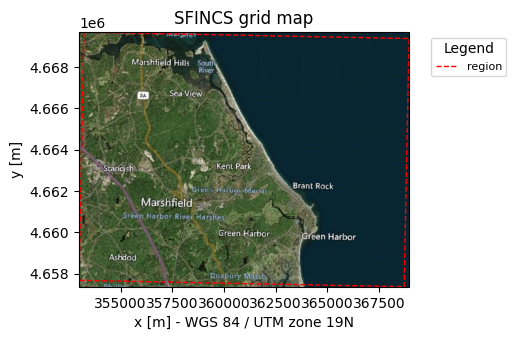

In [3]:
# create domains, handoff points, observations, and physics checks.
from sfincs_runs.build_base.region_setup import build_region_setup

sf = SfincsModel(
    root=str(base_model),
    mode="w+",
    write_gis=True,
)

catalog_sources = {
    "cudem_elv": {
        "uri": str(cudem_tif),
        "data_type": "RasterDataset",
        "driver": {"name": "rasterio"},
    },
    "worldcover": {
        "uri": str(worldcover_tif),
        "data_type": "RasterDataset",
        "driver": {"name": "rasterio"},
    },
}
if usgs_3dep_tif.exists():
    catalog_sources["usgs_3dep"] = {
        "uri": str(usgs_3dep_tif),
        "data_type": "RasterDataset",
        "driver": {"name": "rasterio"},
    }
sf.data_catalog.from_dict(catalog_sources)
print("Catalog sources:", list(sf.data_catalog))

region_setup = build_region_setup(config, paths, buffer_degrees=0.0)
domain_path = Path(region_setup.bbox_output)
study_area_path = Path(region_setup.study_area_path)
land_path = Path(region_setup.coastal_region_output)
offshore_geojson = static_dir / "offshore_region.geojson"
seaward_geojson = static_dir / "seaward_edge.geojson"
waterlevel_boundary_geojson = static_dir / "waterlevel_boundary.geojson"

required = {
    "bbox": domain_path,
    "study area": study_area_path,
    "land polygon": land_path,
    "offshore region": offshore_geojson,
    "seaward edge": seaward_geojson,
    "waterlevel boundary": waterlevel_boundary_geojson,
}
missing = [f"{label} ({path})" for label, path in required.items() if not path.exists()]
if missing:
    raise FileNotFoundError(
        "missing wave-coupling geometry; re-run 01_region_setup.ipynb. Missing: "
        + ", ".join(missing)
    )

model_crs = str(config["project"].get("model_crs") or "EPSG:26919")
domain_gdf = gpd.read_file(domain_path).to_crs(model_crs)
study_area_gdf = gpd.read_file(study_area_path).to_crs(model_crs)
print(f"Domain bounds ({model_crs}): {domain_gdf.total_bounds}")

if not domain_gdf.geometry.union_all().contains(study_area_gdf.geometry.union_all()):
    raise RuntimeError(
        "study area is not contained in the SFINCS domain; redraw the bbox in "
        "01_region_setup.ipynb so it wraps the full grid network"
    )

# Quadtree grid at the configured base resolution.
sf.quadtree_grid.create_from_region(
    region={"geom": str(domain_path)},
    res=float(quadtree_cfg.get("res", 60)),
    rotated=bool(quadtree_cfg.get("rotated", True)),
    crs="utm",
)

print("Grid type:", sf.grid_type)
print("Grid CRS:", sf.crs)
print("Grid extent (UTM):", sf.quadtree_grid.empty_mask.ugrid.total_bounds)

sf.plot_basemap(variable="grid", plot_region=True, plot_bounds=False, bmap="sat", zoomlevel=12)

### Step 2 · Active cell mask

Identical to the surge-only notebook, but calling the quadtree-aware
`sf.quadtree_mask.create_active`.

In [4]:
elevation_layers = [{"elevation": "cudem_elv"}]
if usgs_3dep_tif.exists():
    elevation_layers.append({"elevation": "usgs_3dep"})

sf.quadtree_elevation.create(
    elevation_list=elevation_layers,
    buffer_cells=1,
)

sf.quadtree_mask.create_active(
    include_polygon=gpd.read_file(domain_path).to_crs(sf.crs),
    reset_mask=True,
)

2026-06-25 15:11:07,778 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading cudem_elv RasterDataset data from /home/grahamhults/projects/Flood-RM/locations/marshfield/data/static/processed/cudem_mfield_mesh.tif
2026-06-25 15:11:08,203 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading usgs_3dep RasterDataset data from /home/grahamhults/projects/Flood-RM/locations/marshfield/data/static/raw/topo/usgs_3dep_13_arcsec.tif
2026-06-25 15:11:08,249 - hydromt.data_catalog.adapters.rasterdataset - rasterdataset - WARNING - Dataset [-70.77398148197537, 42.05787036959588, -70.63518518552976, 42.16398148082115] does not fully cover bbox [-70.777, 42.057, -70.587, 42.166]
2026-06-25 15:11:08,255 - hydromt.hydromt_sfincs.components.quadtree.quadtree_elevation - quadtree_elevation - INFO - Processing bathymetry level 1 of 1 ...
2026-06-25 15:11:08,557 - hydromt.hydromt_sfincs.components.quadtree.quadtree_mask - quadtree_mask - INFO - Building mask ...
2026

### Step 3 · Water-level boundary cells

Tags the cells along the `waterlevel_boundary.geojson` strip (written
by 01 as a buffer around the seaward edge) as `mask=2`. These receive
the CORA-derived water level forcing at scenario stage. SnapWave
boundary points (Step 5) reuse the same strip as their open boundary.

Active cells: 51996  |  Water-level boundary cells: 204  |  bnd points: 4


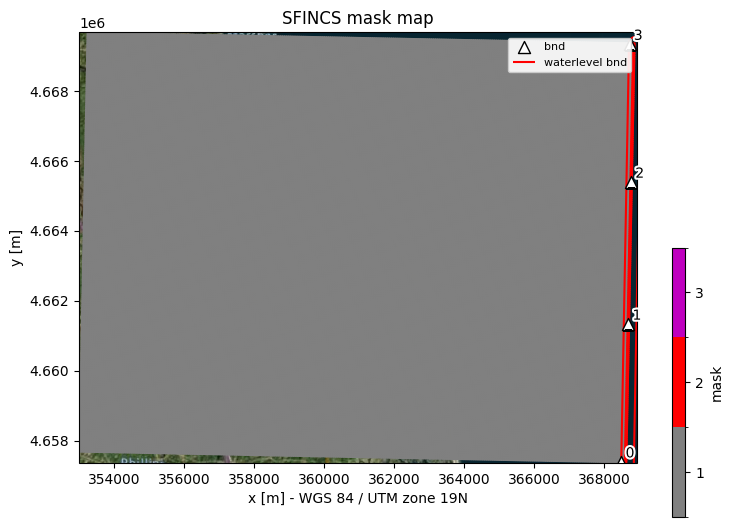

In [5]:
sf.quadtree_mask.create_boundary(
    btype="waterlevel",
    include_polygon=gpd.read_file(waterlevel_boundary_geojson).to_crs(sf.crs),
    reset_bounds=True,
)
sf.water_level.create_boundary_points_from_mask(
    bnd_dist=float(quadtree_cfg.get("waterlevel_boundary_point_spacing_m", 5000.0)),
)

msk = sf.quadtree_mask.data
values = msk["mask"].values
n_wl = int((values == 2).sum())
n_active = int((values == 1).sum())
n_bnd = int(sf.water_level.nr_points)
print(f"Active cells: {n_active}  |  Water-level boundary cells: {n_wl}  |  bnd points: {n_bnd}")

fig, ax = sf.plot_basemap(
    variable="mask", plot_region=False, plot_bounds=False,
    bmap="sat", zoomlevel=12, figsize=(9, 7),
)
gpd.read_file(waterlevel_boundary_geojson).to_crs(sf.crs).boundary.plot(
    ax=ax, color="red", linewidth=1.5, label="waterlevel bnd",
)
ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
plt.show()

### Step 4 · Elevation

Interpolate CUDEM topobathy onto the quadtree faces via
`quadtree_elevation.create`. SnapWave (Step 5) filters wet-vs-dry cells
by elevation, so `z` must be populated before Step 5 runs.

(<Figure size 600x330.62 with 2 Axes>,
 <GeoAxes: title={'center': 'SFINCS z map'}, xlabel='x [m] - WGS 84 / UTM zone 19N', ylabel='y [m]'>)

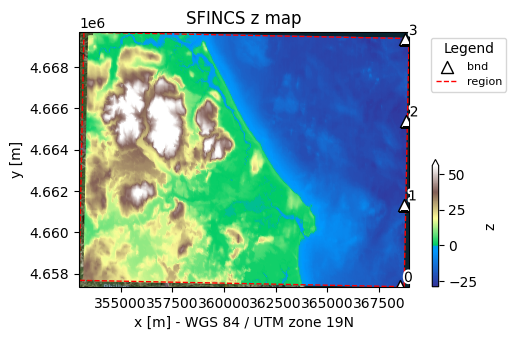

In [6]:
sf.plot_basemap(variable="z", plot_region=True, plot_bounds=False, bmap="sat", zoomlevel=12)

### Step 5 · SnapWave mask + boundary points

Build the SnapWave-specific mask on the quadtree grid: mask==1 in the
offshore region (wave-active cells), mask==2 along the buffered seaward
edge (open-boundary cells where SnapWave forcing is applied). Then
`get_boundary_points_from_mask` walks the mask==2 cells into polylines
and interpolates points at the configured spacing.

The timeseries written here is a constant placeholder. Real wave
forcing (Hs, Tp, mwd, dspr from ERA5) is applied **per event at
scenario stage** using the joint historical analog rule from 
— the same historical analog that supplies water-level forcing must
supply the wave forcing.

In [7]:
# SnapWave mask + boundary points.
# include_polygon = offshore region (wave-active wet cells, mask=1).
# open_boundary_polygon = waterlevel boundary strip (mask=2 along open ocean).
# set wave boundaries, runup gauges, and directional spreading inputs.
from sfincs_runs.snapwave_setup import derive_snapwave_boundary_points

offshore_gdf = gpd.read_file(offshore_geojson).to_crs(sf.crs)
open_boundary_gdf = gpd.read_file(waterlevel_boundary_geojson).to_crs(sf.crs)

sf.quadtree_snapwave_mask.build(
    zmin=99999.0,                
    zmax=-99999.0,
    include_polygon=offshore_gdf,
    include_zmax=0.0,              
    open_boundary_polygon=open_boundary_gdf,
    open_boundary_zmax=0.0,
)

bnd_data = derive_snapwave_boundary_points(
    sf,
    min_dist=float(snapwave_cfg.get("boundary_min_dist", 1500.0)),
    bnd_dist=float(snapwave_cfg.get("boundary_seaward_dist", 5000.0)),
)
print(f"SnapWave boundary points: {len(bnd_data)}")

snapwave_points_geojson = static_dir / "snapwave_boundary_points.geojson"
if not bnd_data.empty:
    # Drop the timeseries DataFrame column before writing GeoJSON.
    bnd_data[["name", "geometry"]].to_file(snapwave_points_geojson, driver="GeoJSON")
    print(f"Wrote {snapwave_points_geojson}")

SnapWave boundary points: 4
Wrote /home/grahamhults/projects/Flood-RM/locations/marshfield/data/static/processed/snapwave_boundary_points.geojson


### Step 6 · SFINCS structures

MassGIS provides the active GIS baseline; WHG/USACE/Town plan sheets provide the design-grade crest elevations. Drainage structures remain out of the base model until invert, opening, rating, and orientation are confirmed.


2026-06-25 15:11:18,094 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading weirs_marshfield_massgis_public_2015.geojson GeoDataFrame data from /home/grahamhults/projects/Flood-RM/locations/marshfield/data/static/structures/processed/weirs_marshfield_massgis_public_2015.geojson
2026-06-25 15:11:18,186 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading thin_dams_marshfield_massgis_public_2015.geojson GeoDataFrame data from /home/grahamhults/projects/Flood-RM/locations/marshfield/data/static/structures/processed/thin_dams_marshfield_massgis_public_2015.geojson


,layer,decision,kind,feature_count,path,reason
0,weirs,applied,weir,25,/home/grahamhults/projects/Flood-RM/locations/...,
1,thin_dams,applied,thin_dam,6,/home/grahamhults/projects/Flood-RM/locations/...,


Structure figure: /home/grahamhults/projects/Flood-RM/locations/marshfield/data/sfincs/figures/structures/marshfield_sfincs_structure_layers_map.png


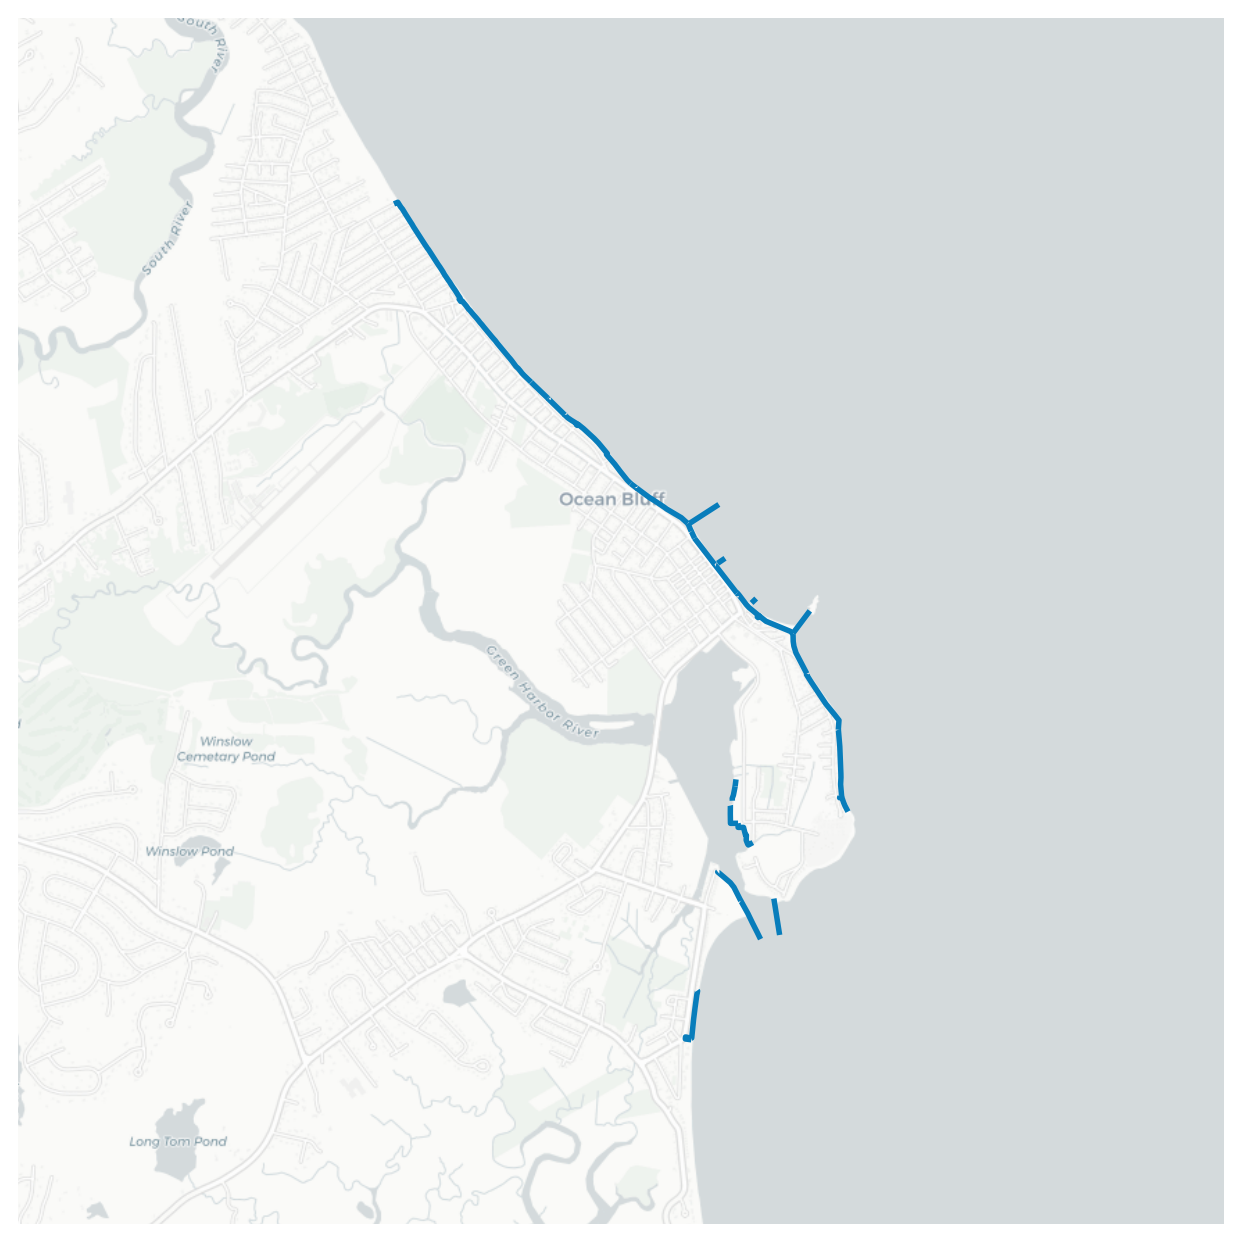

In [8]:
from IPython.display import Image
# create domains, handoff points, observations, and physics checks.
from sfincs_runs.build_base.structures import apply_sfincs_structures, plot_structure_layers, prepare_structure_layers

# MassGIS-derived SFINCS Structure Layers
structure_plan = prepare_structure_layers(config, paths)
apply_sfincs_structures(sf, structure_plan)
structure_rows = pd.DataFrame(structure_plan.summary_rows())
display(structure_rows)

structures_cfg = config.get("sfincs_structures") or {}
structures_figures = (
    Path(structures_cfg.get("figures_root", "data/sfincs/figures/structures"))
    if Path(structures_cfg.get("figures_root", "data/sfincs/figures/structures")).is_absolute()
    else paths["location_root"] / structures_cfg.get("figures_root", "data/sfincs/figures/structures")
)
structure_figure = plot_structure_layers(
    structure_plan,
    output_path=structures_figures / "marshfield_sfincs_structure_layers_map.png",
    map_context=True,
    single_color="#087dbb",
)
print("Structure figure:", structure_figure)
display(Image(filename=str(structure_figure)))

### Step 7 · Subgrid (elevation + roughness)

Build the SFINCS subgrid table on the quadtree grid. Combines CUDEM
topobathy with WorldCover-derived Manning's n via the ESA reclass table
bundled with hydromt-sfincs. Effective subgrid resolution =
`quadtree.res / quadtree.nr_subgrid_pixels` (e.g. 60 m / 6 = 10 m).

Subgrid: 6 pixels per cell (10.00 m effective)
2026-06-25 15:11:23,342 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading cudem_elv RasterDataset data from /home/grahamhults/projects/Flood-RM/locations/marshfield/data/static/processed/cudem_mfield_mesh.tif
2026-06-25 15:11:23,424 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading usgs_3dep RasterDataset data from /home/grahamhults/projects/Flood-RM/locations/marshfield/data/static/raw/topo/usgs_3dep_13_arcsec.tif
2026-06-25 15:11:23,442 - hydromt.data_catalog.adapters.rasterdataset - rasterdataset - WARNING - Dataset [-70.77398148197537, 42.05787036959588, -70.63518518552976, 42.16398148082115] does not fully cover bbox [-70.777, 42.057, -70.587, 42.166]
2026-06-25 15:11:23,477 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading worldcover RasterDataset data from /home/grahamhults/projects/Flood-RM/locations/marshfield/data/static/processed/worldcover_mfield_mesh.tif
2

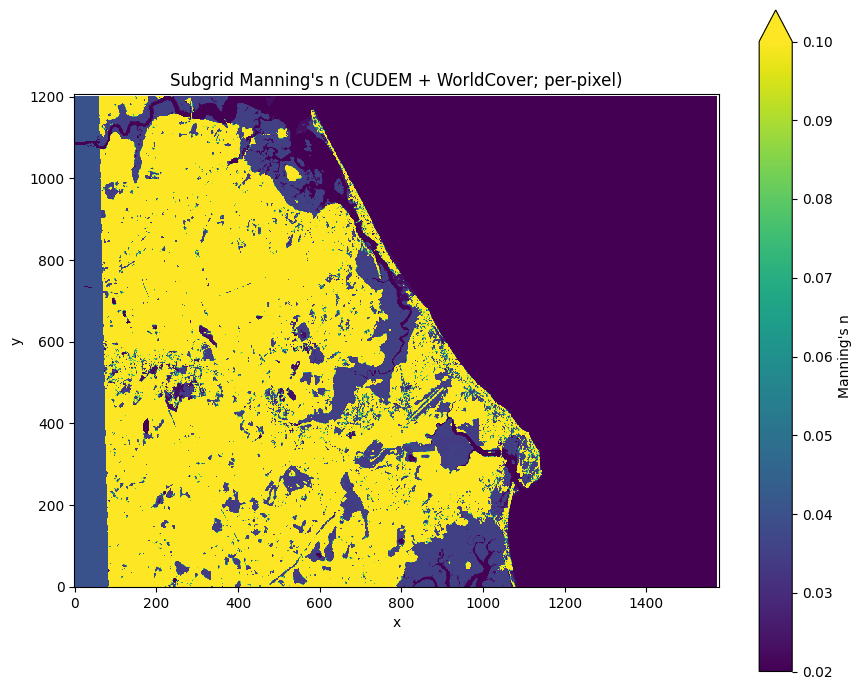

In [9]:
roughness_list = [
    {"lulc": "worldcover", "reclass_table": str(esa_mapping)},
]

nr_subgrid_pixels = int(quadtree_cfg.get("nr_subgrid_pixels", 6))
if nr_subgrid_pixels % 2 != 0:
    raise ValueError(
        f"nr_subgrid_pixels must be a multiple of 2 (got {nr_subgrid_pixels}); "
        "hydromt-sfincs requires this for the subgrid table"
    )
print(
    f"Subgrid: {nr_subgrid_pixels} pixels per cell "
    f"({float(quadtree_cfg.get('res', 60)) / nr_subgrid_pixels:.2f} m effective)"
)

bathymetry_sets = [{"elevation": "cudem_elv"}]
if usgs_3dep_tif.exists():
    bathymetry_sets.append({"elevation": "usgs_3dep"})

sf.quadtree_subgrid.create(
    bathymetry_sets=bathymetry_sets,
    roughness_list=roughness_list,
    manning_land=0.04,
    manning_water=0.02,
    nr_subgrid_pixels=nr_subgrid_pixels,
    write_dep_tif=True,
    write_man_tif=True,
)

# for plotting manning's n
manning_tif = base_model / "subgrid" / "manning_subgrid_lev0.tif"
if manning_tif.exists():
    fig, ax = plt.subplots(figsize=(9, 7))
    rxr.open_rasterio(manning_tif, masked=True).squeeze(drop=True).plot.imshow(
        ax=ax, cmap="viridis", vmin=0.02, vmax=0.10,
        cbar_kwargs={"label": "Manning's n"},
    )
    ax.set_title("Subgrid Manning's n (CUDEM + WorldCover; per-pixel)")
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()
else:
    print(f"manning tif not found at {manning_tif}; skipping roughness plot")


### Step 7b · Hydrology gate (rainfall + infiltration)

Rain-on-grid runs must not fall back to `qinf = 0`. When rainfall or
soil-moisture drivers are enabled, this cell requires an explicit SFINCS
infiltration method and source data. The preferred setup for this study is
Curve Number with recovery: land cover, HSG, Ksat, a CN reclass table, and
an event-specific effective soil-retention fraction derived from antecedent
soil moisture.


In [10]:
# add infiltration/soil inputs used by SFINCS rainfall runs.
from sfincs_runs.hydrology import setup_hydromt_infiltration

# Hydrology / infiltration setup. Precipitation is event-specific and is
# staged in the single-event run cell below; infiltration maps are static model
# inputs and must be written with the base model.
infiltration_summary = setup_hydromt_infiltration(sf, config, paths, datadir=DATADIR)
hydrology_enabled = bool(infiltration_summary["enabled"])
hydrologic_drivers = set(infiltration_summary["drivers"])
print("Hydrology enabled:", hydrology_enabled)
print("Hydrologic event drivers:", sorted(hydrologic_drivers))
print("Infiltration method:", infiltration_summary["method"])
print("Infiltration files written:", infiltration_summary["written"])

ksat_conditioning = infiltration_summary.get("ksat_conditioning")
if ksat_conditioning:
    print("Effective Ksat raster:", ksat_conditioning["ksat"])
    print(
        "Ksat conditioning:",
        f"scale={ksat_conditioning['scale_factor']}",
        f"max={ksat_conditioning['max_mmhr']} mm/hr",
        f"capped_fraction={ksat_conditioning['capped_fraction']:.3f}",
    )


2026-06-25 15:11:45,396 - hydromt.hydromt_sfincs.components.quadtree.quadtree_infiltration - quadtree_infiltration - INFO - Creating curve number values for SFINCS quadtree grid including recovery term.
2026-06-25 15:11:45,431 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading worldcover RasterDataset data from /home/grahamhults/projects/Flood-RM/locations/marshfield/data/static/processed/worldcover_mfield_mesh.tif
2026-06-25 15:11:45,486 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading hsg RasterDataset data from /home/grahamhults/projects/Flood-RM/locations/marshfield/data/static/soils/hsg_mfield.tif
2026-06-25 15:11:45,543 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading ksat RasterDataset data from /home/grahamhults/projects/Flood-RM/locations/marshfield/data/static/soils/ksat_mmhr_mfield_effective.tif
2026-06-25 15:11:45,565 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading esa_worldco

### Step 8 · Runup gauges (rugfile)

Read `coastal_wave_coupling.runup_gauges.transects` from `config.yaml`
and write the official SFINCS `rugfile`. Each transect is a 2-vertex
line (SFINCS reads only the first two); the file is consumed at runtime
by the mt_Faber-branch runup-gauge logic. `rugfile` and `rugdepth` keys
are injected into `sfincs.inp` in Step 9 because they are not yet part
of the hydromt-sfincs 2.0.0rc1 schema .


In [11]:
# set wave boundaries, runup gauges, and directional spreading inputs.
from sfincs_runs.snapwave_setup import validate_runup_transects, write_runup_gauges_file

# Build runup-gauge transects from config and write the SFINCS rugfile.
# Each transect is a line from (x0,y0) to (x1,y1) in the configured CRS;
# SFINCS reads only the first two vertices.
transects = []
for entry in (runup_cfg.get("transects") or []):
    transects.append((
        str(entry["name"]),
        (float(entry["x0"]), float(entry["y0"])),
        (float(entry["x1"]), float(entry["y1"])),
    ))

rugfile_path = base_model / "sfincs.rug"
if transects:
    validate_runup_transects(transects, domain_gdf.geometry.union_all())
    write_runup_gauges_file(rugfile_path, transects)
    print(f"Wrote {rugfile_path} with {len(transects)} transect(s)")
else:
    print("No runup_gauges.transects configured — skipping rugfile write")

Wrote /home/grahamhults/projects/Flood-RM/locations/marshfield/data/sfincs/base_quadtree_snapwave/sfincs.rug with 2 transect(s)


### Step 9 · Write base model + repair wave/runup inputs

Write all hydromt-sfincs components (grid, masks, elevation, subgrid,
SnapWave mask, SnapWave boundary conditions, SFINCS structures) to the base model
directory. Then repair two mt_Faber/hydromt-sfincs integration gaps:
rewrite `snapwave.bds` with a valid directional-spreading time axis, and
inject the official `rugfile` / `rugdepth` keys plus the observation-file
workaround required by the current mt_Faber runup-gauge reader.

`snapwave=1` activates the SnapWave solver in the mt_Faber SFINCS
binary; the `sfincs-snapwave_latest.sif` Apptainer image is the only
one that recognises it (per 's binary distribution decision).


In [12]:
# set wave boundaries, runup gauges, and directional spreading inputs.
from sfincs_runs.snapwave_setup import (
    inject_runup_config,
    repair_snapwave_directional_spreading_file,
)

# SnapWave + epsg config. snapwave=1 activates the SnapWave solver in the
# mt_Faber SFINCS binary (sfincs-snapwave_latest.sif per ).
sf.config.update({
    "epsg": int(sf.crs.to_epsg()),
    "storevel": 1,
    "snapwave": 1,
})

sf.write()
print("Base model written to:", base_model)

# hydromt-sfincs 2.0.0rc1 currently writes snapwave.bds by reusing the
# wave-direction dataframe; rewrite it with the bhs time axis and a
# constant directional spread before staging any runs.
bds_path = repair_snapwave_directional_spreading_file(
    base_model,
    spread_degrees=float(snapwave_cfg.get("directional_spread_degrees", 20.0)),
)
print(f"Repaired SnapWave directional spreading file: {bds_path}")

# rugfile / rugdepth are not yet in the hydromt-sfincs 2.0.0rc1 schema
# . Inject them directly into sfincs.inp after sf.write.
# The helper also writes a one-point obsfile workaround for the current
# mt_Faber runup-gauge reader, which checks obsfile before opening rugfile.
if transects:
    inject_runup_config(
        base_model / "sfincs.inp",
        rugfile="sfincs.rug",
        rugdepth=float(runup_cfg.get("rugdepth", 0.05)),
    )
    print(f"Injected rugfile/rugdepth/obsfile into {base_model / 'sfincs.inp'}")

2026-06-25 15:11:46,262 - hydromt.hydromt_sfincs.components.config.config - config - INFO - Updating 3 attributes in model config.
2026-06-25 15:11:46,339 - hydromt.hydromt_sfincs.components.quadtree.quadtree_infiltration - quadtree_infiltration - INFO - Checking for infiltration variables in quadtree grid data...
2026-06-25 15:11:46,340 - hydromt.hydromt_sfincs.components.quadtree.quadtree_infiltration - quadtree_infiltration - INFO - Available data variables: ['crs', 'level', 'z', 'mask', 'snapwave_mask', 'n', 'm', 'mu', 'mu1', 'mu2', 'md', 'md1', 'md2', 'nu', 'nu1', 'nu2', 'nd', 'nd1', 'nd2']
2026-06-25 15:11:46,341 - hydromt.hydromt_sfincs.components.quadtree.quadtree_infiltration - quadtree_infiltration - INFO - ✗ Missing qinf
2026-06-25 15:11:46,341 - hydromt.hydromt_sfincs.components.quadtree.quadtree_infiltration - quadtree_infiltration - INFO - ✗ Missing scs
2026-06-25 15:11:46,342 - hydromt.hydromt_sfincs.components.quadtree.quadtree_infiltration - quadtree_infiltration - INF